In [1]:
begin
    using Pkg
    dev_folder = joinpath(@__DIR__, "../Examples")
    Pkg.activate(dev_folder)
end
Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [2]:
using Polyhedra
using GLMakie # for plotting, we use Makie backend, could also be GLMakie or WGLMakie...
using Revise
using BindingAndCatalysis # import the package

In [3]:
N = [1 0 1 0 -1 0 
     0 1 0 1 0 -1]

2×6 Matrix{Int64}:
 1  0  1  0  -1   0
 0  1  0  1   0  -1

In [4]:
model1 = Bnc(N=N)

----------Binding Network Summary:-------------
Number of species (n): 6
Number of conserved quantities (d): 4
Number of reactions (r): 2
L matrix: [1 0 … 1 0; 0 1 … 0 1; 0 0 … 1 0; 0 0 … 0 1]
N matrix: [1 0 … -1 0; 0 1 … 0 -1]
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

In [5]:
f,ax = draw_graph(model1)

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 16 vertices found and 16 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: 2.Calculating nullity for each vertex in parallel...
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Start calculating vertices neighbor graph, It may takes a while.
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Calculating vertices neighbor graph with qK change dir
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Number of polyhedra to calc volume: 9
[ Info: All regimes converged after 1300000 samples.


(Scene(1 children, 0 plots), Axis (2 plots), Plot{GraphMakie.graphplot, Tuple{Graphs.SimpleGraphs.SimpleDiGraph{Int64}}})

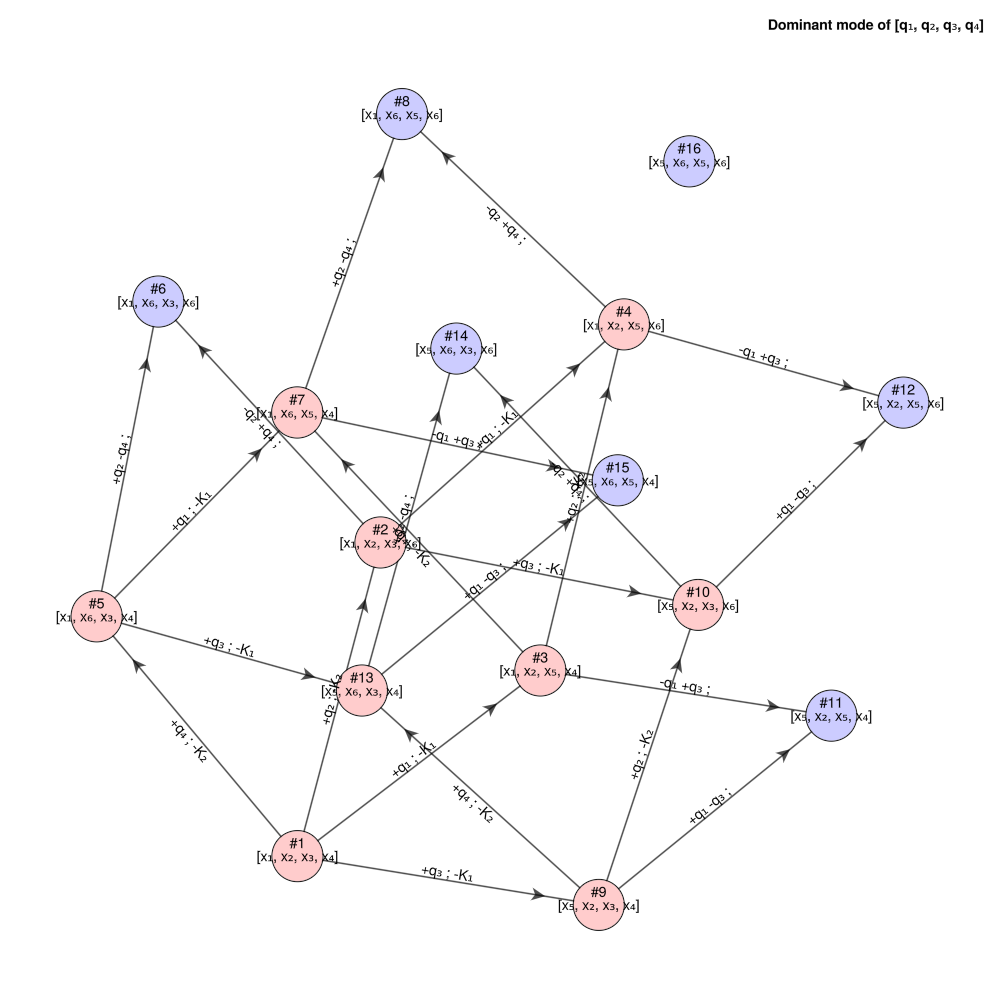

In [6]:
f

In [7]:
p = SISOPaths(model1,1)

[ Info: sources: [5, 13, 2, 10, 9, 1]
[ Info: sinks: [4, 7, 3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 16
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 6


SISOPaths{Int8}(Bnc{Int8}([1 0 … -1 0; 0 1 … 0 -1], [1 0 … 1 0; 0 1 … 0 1; 0 0 … 1 0; 0 0 … 0 1], 2, 6, 4, Symbolics.Num[x₁, x₂, x₃, x₄, x₅, x₆], Symbolics.Num[q₁, q₂, q₃, q₄], Symbolics.Num[K₁, K₂], nothing, Vector{Int8}[[1, 2, 3, 4], [1, 2, 3, 6], [1, 2, 5, 4], [1, 2, 5, 6], [1, 6, 3, 4], [1, 6, 3, 6], [1, 6, 5, 4], [1, 6, 5, 6], [5, 2, 3, 4], [5, 2, 3, 6], [5, 2, 5, 4], [5, 2, 5, 6], [5, 6, 3, 4], [5, 6, 3, 6], [5, 6, 5, 4], [5, 6, 5, 6]], Dict{Vector{Int8}, Int64}([1, 2, 5, 4] => 3, [1, 2, 5, 6] => 4, [5, 2, 3, 4] => 9, [5, 2, 3, 6] => 10, [5, 6, 5, 4] => 15, [1, 2, 3, 4] => 1, [1, 2, 3, 6] => 2, [5, 6, 5, 6] => 16, [1, 6, 5, 4] => 7, [1, 6, 5, 6] => 8…), Bool[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], Int8[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 2], BindingAndCatalysis.VertexGraph{Int8}(Bnc{Int8}(#= circular reference @-2 =#), Graphs.SimpleGraphs.SimpleGraph{Int64}(32, [[2, 3, 5, 9], [1, 4, 6, 10], [1, 4, 7, 11], [2, 3, 8, 12], [1, 6, 7, 13], [2, 5, 8, 14], [3, 5, 8, 15

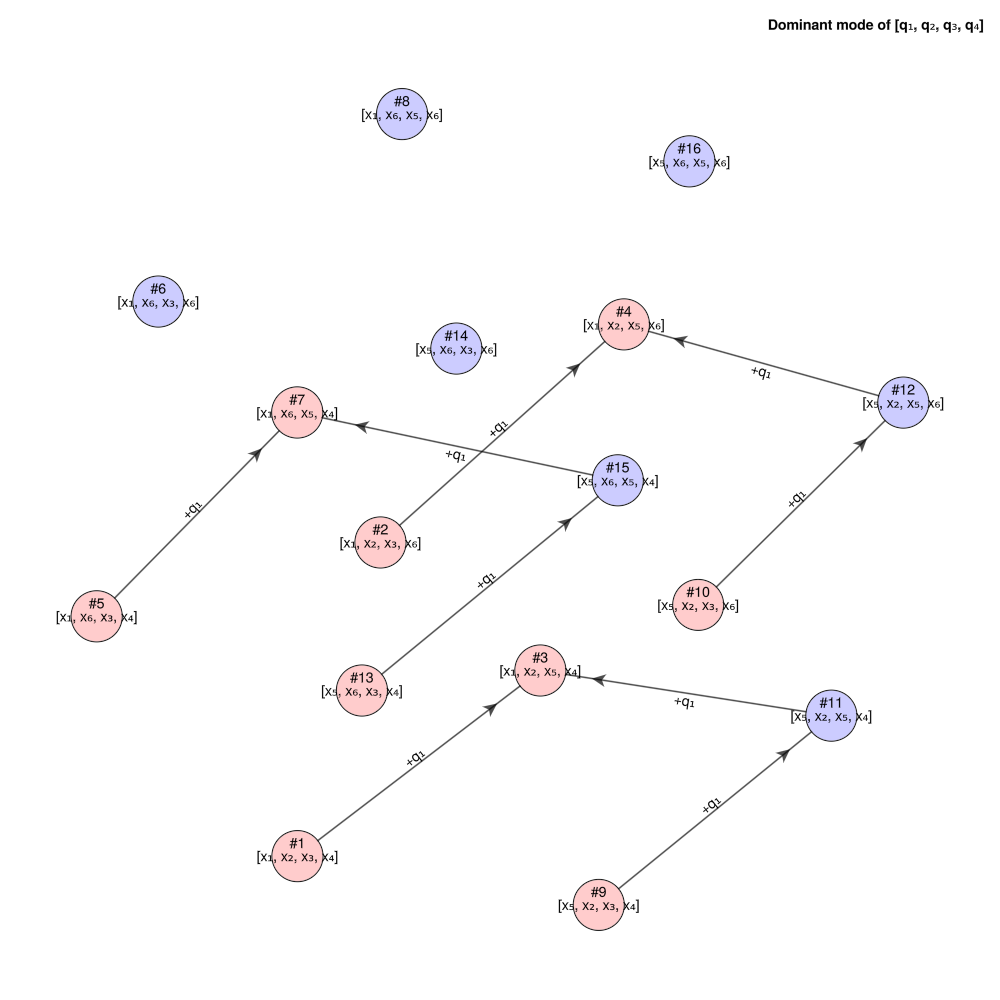

In [9]:
f,ax = draw_graph(p);
f

In [10]:
summary(p)

[ Info: Start building polyhedra for edges (total: 9)
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Start building polyhedra for paths (total: 6)
Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
[ Info: Number of polyhedra to calc volume: 6


Path 1         #1 → #3         Volume: 0.1667 ± 0.0008
Path 2         #2 → #4         Volume: 0.1667 ± 0.0008


[ Info: All regimes converged after 800000 samples.


Path 3         #5 → #7         Volume: 0.1662 ± 0.0008
Path 4         #9 → #11 → #3   Volume: 0.1665 ± 0.0008
Path 5         #10 → #12 → #4  Volume: 0.1673 ± 0.0008
Path 6         #13 → #15 → #7  Volume: 0.1666 ± 0.0008
